In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import torch.optim as optim
from tqdm.notebook import tqdm
import pytorch_model_summary

# Generating Data
(단순 대칭성만을 가진 데이터, DeepSet)

In [2]:
def generate_data(n=10000):
    x1 = np.random.uniform(-2, 2, size=(n, 1))
    x2 = np.random.uniform(-2, 2, size=(n, 1))

    X = np.concatenate([x1, x2], axis=1)

    Y = (x1**2 + x2**2 + np.sin(x1 + x2))

    return torch.tensor(X, dtype=torch.float32), \
           torch.tensor(Y, dtype=torch.float32)

In [5]:
device = torch.device('mps' if torch.backends.mps.is_available() and torch.backends.mps.is_built() else 'cpu')
X_train, Y_train = generate_data(50000)
X_test,  Y_test  = generate_data(10000)

In [27]:
X_train = X_train.to(device)
X_test  = X_test.to(device)
Y_train = Y_train.to(device)
Y_test  = Y_test.to(device)

In [7]:
torch.save(X_train, './data/X_train.pt')
torch.save(X_test,  './data/X_test.pt')
torch.save(Y_train, './data/Y_train.pt')
torch.save(Y_test,  './data/Y_test.pt')

# Defining

In [39]:
class SharedLinear(nn.Module):
    def __init__(self, in_dim=1, out_dim=32, is_last=False):
        super().__init__()
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.is_last = is_last

        self.A = nn.Parameter(torch.randn(out_dim, in_dim) * 0.1)
        self.B = nn.Parameter(torch.randn(out_dim, in_dim) * 0.1)

        self.bias = nn.Parameter(torch.zeros(out_dim))

    def forward(self, x):
        x1 = x[:, :self.in_dim]
        x2 = x[:, self.in_dim:]

        out1 = x1 @ self.A.T + x2 @ self.B.T + self.bias
        out2 = x1 @ self.B.T + x2 @ self.A.T + self.bias

        if self.is_last:
            return out1 + out2
        else:
            return torch.cat([out1, out2], dim=1)

In [35]:
def train(model, X, Y, epochs=1000):
    train_log = []
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    bar = tqdm(range(epochs), desc = 'training')
    for epoch in bar:
        optimizer.zero_grad()
        pred = model(X)
        loss = criterion(pred, Y)
        loss.backward()
        optimizer.step()
        bar.set_description(f'loss : {loss.item():.6f}')
        train_log.append(loss.item())

    return train_log

@torch.no_grad()
def evaluate(name, model, X_test, Y_test):
    pred = model(X_test)
    loss = nn.MSELoss()(pred, Y_test).item()
    sym = symmetry_error(model, X_test)

    print(f"{name}")
    print(f"  Loss: {loss:.6f}")
    print(f"  Symmetry error: {sym:.6e}")
    return loss, sym

@torch.no_grad()
def symmetry_error(model, X):
    x1 = X.clone()
    x2 = X[:, [1, 0]]  # swap

    y1 = model(x1)
    y2 = model(x2)

    return torch.mean(torch.abs(y1 - y2)).item()

def display_log(history1, history2, name1, name2):
    size = len(history1)
    plt.figure(figsize = (10, 6))
    plt.plot(np.arange(1, size + 1), history1, label = name1)
    plt.plot(np.arange(1, size + 1), history2, label = name2)
    plt.legend()
    plt.grid()
    plt.show()

# Model1

In [47]:
vanilla_model1 = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),
    nn.Linear(16, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 4),
    nn.ReLU(),
    nn.Linear(4, 1)
)

shared_model1 = nn.Sequential(
    SharedLinear(in_dim = 1, out_dim = 8),
    nn.ReLU(),
    SharedLinear(in_dim = 8, out_dim = 16),
    nn.ReLU(),
    SharedLinear(in_dim = 16, out_dim = 8),
    nn.ReLU(),
    SharedLinear(in_dim = 8, out_dim = 4),
    nn.ReLU(),
    SharedLinear(in_dim = 4, out_dim = 2),
    nn.ReLU(),
    SharedLinear(2, 1, is_last = True)
)

vanilla_model1.to(device)
shared_model1.to(device)

'.'

'.'

In [48]:
print('\n\nvanila model1')
print(pytorch_model_summary.summary(vanilla_model1, torch.zeros(2, device = device)))

print('\n\nequiv model1')
print(pytorch_model_summary.summary(shared_model1, torch.zeros(1,2, device = device)))



vanila model1
-----------------------------------------------------------------------
      Layer (type)        Output Shape         Param #     Tr. Param #
          Linear-1                [16]              48              48
            ReLU-2                [16]               0               0
          Linear-3                [32]             544             544
            ReLU-4                [32]               0               0
          Linear-5                [16]             528             528
            ReLU-6                [16]               0               0
          Linear-7                 [8]             136             136
            ReLU-8                 [8]               0               0
          Linear-9                 [4]              36              36
           ReLU-10                 [4]               0               0
         Linear-11                 [1]               5               5
Total params: 1,297
Trainable params: 1,297
Non-trainable pa

In [ ]:
print("--- Vanilla MLP 학습 ---")
valina_log1 = train(vanilla_model1, X_train, Y_train, 100)
print("\n--- Equivariant MLP 학습 ---")
shared_log1  = train(shared_model1,  X_train, Y_train, 100)

--- Vanilla MLP 학습 ---


training:   0%|          | 0/100 [00:00<?, ?it/s]


--- Equivariant MLP 학습 ---


training:   0%|          | 0/100 [00:00<?, ?it/s]

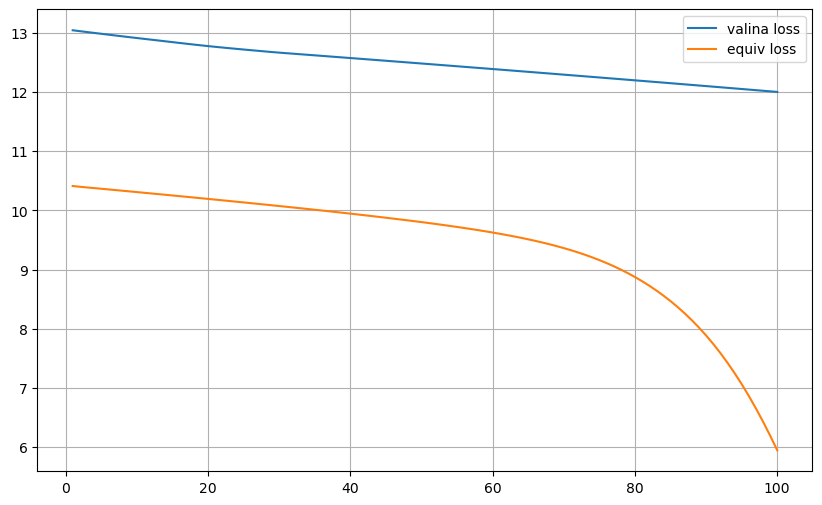

In [ ]:
display_log(valina_log1, shared_log1, 'valina loss', 'equiv loss')

In [52]:
evaluate("Vanilla MLP",     vanilla_model1, X_test, Y_test)
evaluate("Equivariant MLP", shared_model1,   X_test, Y_test)

Vanilla MLP
  Loss: 11.999858
  Symmetry error: 0.000000e+00
Equivariant MLP
  Loss: 5.692061
  Symmetry error: 0.000000e+00


(5.692061424255371, 0.0)

In [ ]:
import pickle

torch.save(shared_model1.state_dict(), './models/equiv_model1_0408.pt')
torch.save(vanilla_model1.state_dict(), './models/vanilla_model1_0408.pt')

with open('./logs/shared_log1_0408.pkl', 'wb') as f:
    pickle.dump(equiv_log1, f)
with open('./logs/vanilla_log1_0408.pkl', 'wb') as f:
    pickle.dump(valina_log1, f)

mkdir: ./models: File exists
